**Interpretable 30-Day Readmission Risk Prediction**
    
Goal

Predict whether a patient will be readmitted within 30 days after discharge, and output:

* risk probability
* risk tier (Low / Med / High)
* top reasons (SHAP)
* suggested follow-up action (rule-based mapping)

In [ ]:
#  Imports & Global Settings
import os, json, joblib, zipfile
import numpy as np
import pandas as pd

import scipy.sparse as sp
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, f1_score
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Paths
MIMIC_ROOT = "/content/drive/MyDrive/mimic/mimiciv_3_1_full/mimic-iv-3.1"
HOSP_DIR = os.path.join(MIMIC_ROOT, "hosp")
ICU_DIR  = os.path.join(MIMIC_ROOT, "icu")

OUT_BASE = "/content/drive/MyDrive/mimic"
MODELS_DIR = os.path.join(OUT_BASE, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

print("MIMIC_ROOT:", MIMIC_ROOT)
print("hosp exists?", os.path.exists(HOSP_DIR))
print("icu exists? ", os.path.exists(ICU_DIR))
print("Hosp sample:", sorted(os.listdir(HOSP_DIR))[:8])
print("ICU sample :", sorted(os.listdir(ICU_DIR))[:8])

MIMIC_ROOT: /content/drive/MyDrive/mimic/mimiciv_3_1_full/mimic-iv-3.1
hosp exists? True
icu exists?  True
Hosp sample: ['admissions.csv.gz', 'd_hcpcs.csv.gz', 'd_icd_diagnoses.csv.gz', 'd_icd_procedures.csv.gz', 'd_labitems.csv.gz', 'diagnoses_icd.csv.gz', 'drgcodes.csv.gz', 'emar.csv.gz']
ICU sample : ['caregiver.csv.gz', 'chartevents.csv.gz', 'd_items.csv.gz', 'datetimeevents.csv.gz', 'icustays.csv.gz', 'ingredientevents.csv.gz', 'inputevents.csv.gz', 'outputevents.csv.gz']


**Load core tables (RAM-safe)**

We load small/medium tables directly:

* patients
* admissions
* diagnoses_icd
* d_labitems

We do NOT load labevents.csv.gz fully — we process it by chunks only when building lab features.

In [ ]:
# Load core hospital tables
patients_path   = os.path.join(HOSP_DIR, "patients.csv.gz")
admissions_path = os.path.join(HOSP_DIR, "admissions.csv.gz")
dx_path         = os.path.join(HOSP_DIR, "diagnoses_icd.csv.gz")
d_labs_path     = os.path.join(HOSP_DIR, "d_labitems.csv.gz")
labs_path       = os.path.join(HOSP_DIR, "labevents.csv.gz")

patients   = pd.read_csv(patients_path, compression="gzip")
admissions = pd.read_csv(admissions_path, compression="gzip")
diagnoses  = pd.read_csv(dx_path, compression="gzip")
d_labitems = pd.read_csv(d_labs_path, compression="gzip")

print("Loaded:")
print("patients  :", patients.shape)
print("admissions:", admissions.shape)
print("diagnoses :", diagnoses.shape)
print("d_labitems:", d_labitems.shape)

Loaded:
patients  : (364627, 6)
admissions: (546028, 16)
diagnoses : (6364488, 5)
d_labitems: (1650, 4)


In [ ]:
def preview(df, name, n=5):
    print(f"\n--- {name} ---")
    print("shape:", df.shape)
    print("columns:", list(df.columns))
    display(df.head(n))

preview(patients, "patients")
preview(admissions, "admissions")
preview(diagnoses, "diagnoses_icd")
preview(d_labitems, "d_labitems")


--- patients ---
shape: (364627, 6)
columns: ['subject_id', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod']


,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13



--- admissions ---
shape: (546028, 16)
columns: ['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admit_provider_id', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'edregtime', 'edouttime', 'hospital_expire_flag']


,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaN,EW EMER.,P784FA,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaN,EW EMER.,P19UTS,EMERGENCY ROOM,HOSPICE,Medicaid,English,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,EW EMER.,P06OTX,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaN,EU OBSERVATION,P39NWO,EMERGENCY ROOM,NaN,NaN,English,SINGLE,WHITE,2160-03-03 21:55:00,2160-03-04 06:26:00,0



--- diagnoses_icd ---
shape: (6364488, 5)
columns: ['subject_id', 'hadm_id', 'seq_num', 'icd_code', 'icd_version']


,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10000032,22595853,1,5723,9
1,10000032,22595853,2,78959,9
2,10000032,22595853,3,5715,9
3,10000032,22595853,4,07070,9
4,10000032,22595853,5,496,9



--- d_labitems ---
shape: (1650, 4)
columns: ['itemid', 'label', 'fluid', 'category']


,itemid,label,fluid,category
0,50801,Alveolar-arterial Gradient,Blood,Blood Gas
1,50802,Base Excess,Blood,Blood Gas
2,50803,"Calculated Bicarbonate, Whole Blood",Blood,Blood Gas
3,50804,Calculated Total CO2,Blood,Blood Gas
4,50805,Carboxyhemoglobin,Blood,Blood Gas


**Build cohort_raw_full (admissions + patients)**

This is the base table we use for labeling readmission and feature engineering.

In [ ]:
COHORT_RAW_PATH = os.path.join(OUT_BASE, "cohort_raw_full.csv")

if os.path.exists(COHORT_RAW_PATH):
    print("Found:", COHORT_RAW_PATH)
    cohort_raw = pd.read_csv(COHORT_RAW_PATH)
else:
    cohort_raw = admissions.merge(
        patients[["subject_id", "gender", "anchor_age", "anchor_year", "anchor_year_group"]],
        on="subject_id", how="left"
    )
    cohort_raw.to_csv(COHORT_RAW_PATH, index=False)
    print("Saved:", COHORT_RAW_PATH)

print("cohort_raw shape:", cohort_raw.shape)
display(cohort_raw.head())

Found: /content/drive/MyDrive/mimic/cohort_raw_full.csv
cohort_raw shape: (546028, 20)


,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,gender,anchor_age,anchor_year,anchor_year_group
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,F,52,2180,2014 - 2016
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaN,EW EMER.,P784FA,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0,F,52,2180,2014 - 2016
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaN,EW EMER.,P19UTS,EMERGENCY ROOM,HOSPICE,Medicaid,English,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0,F,52,2180,2014 - 2016
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,EW EMER.,P06OTX,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0,F,52,2180,2014 - 2016
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaN,EU OBSERVATION,P39NWO,EMERGENCY ROOM,NaN,NaN,English,SINGLE,WHITE,2160-03-03 21:55:00,2160-03-04 06:26:00,0,F,19,2160,2008 - 2010


**Label 30-day readmission (readmit_30d)**

Definition:

* For each admission (hadm_id), find the next admission for that patient.
* If the next admission starts within 0–30 days after discharge, label = 1.
* We filter out in-hospital deaths to keep the label consistent.

In [ ]:
COHORT_LABELED_PATH = os.path.join(OUT_BASE, "cohort_labeled_full.csv")

if os.path.exists(COHORT_LABELED_PATH):
    cohort = pd.read_csv(COHORT_LABELED_PATH)
    print("Loaded cached cohort_labeled_full:", COHORT_LABELED_PATH)
else:
    cohort = cohort_raw.copy()

    # Parse datetime columns
    for col in ["admittime", "dischtime", "deathtime", "edregtime", "edouttime"]:
        if col in cohort.columns:
            cohort[col] = pd.to_datetime(cohort[col], errors="coerce")

    cohort = cohort.sort_values(["subject_id", "admittime"]).reset_index(drop=True)

    cohort["next_admittime"] = cohort.groupby("subject_id")["admittime"].shift(-1)
    cohort["days_to_next_admit"] = (cohort["next_admittime"] - cohort["dischtime"]).dt.total_seconds() / (24*3600)

    cohort["readmit_30d"] = (
        (cohort["days_to_next_admit"] >= 0) & (cohort["days_to_next_admit"] <= 30)
    ).astype(int)

    # Filter out in-hospital deaths for modeling
    model_df = cohort[cohort["hospital_expire_flag"] == 0].copy()
    if "discharge_location" in model_df.columns:
        model_df = model_df[model_df["discharge_location"].fillna("").str.upper() != "DIED"].copy()

    model_df.to_csv(COHORT_LABELED_PATH, index=False)
    cohort = model_df
    print("Saved cohort_labeled_full:", COHORT_LABELED_PATH)

print("Rows:", len(cohort))
print("Unique patients:", cohort["subject_id"].nunique())
print("Readmit rate:", cohort["readmit_30d"].mean())

Loaded cached cohort_labeled_full: /content/drive/MyDrive/mimic/cohort_labeled_full.csv
Rows: 534000
Unique patients: 218105
Readmit rate: 0.20473595505617978


**Feature engineering v1 (discharge-time features)**

We create structured discharge-time features:

* LOS (length of stay)
* ED LOS + missingness
* prior admits + days since last discharge
* SNF discharge flag

In [ ]:
FEATURES_V1_PATH = os.path.join(OUT_BASE, "features_v1_full.csv")

if os.path.exists(FEATURES_V1_PATH):
    model_df = pd.read_csv(FEATURES_V1_PATH)
    print("Loaded cached features_v1_full:", FEATURES_V1_PATH)
else:
    model_df = cohort.copy()

    for col in ["admittime","dischtime","edregtime","edouttime"]:
        if col in model_df.columns:
            model_df[col] = pd.to_datetime(model_df[col], errors="coerce")

    model_df = model_df.sort_values(["subject_id","admittime"]).reset_index(drop=True)

    model_df["los_days"] = (model_df["dischtime"] - model_df["admittime"]).dt.total_seconds() / (24*3600)

    model_df["ed_los_hours"] = (model_df["edouttime"] - model_df["edregtime"]).dt.total_seconds() / 3600
    model_df["ed_times_missing"] = model_df["ed_los_hours"].isna().astype(int)

    model_df["prior_admits_all"] = model_df.groupby("subject_id").cumcount()
    model_df["prev_dischtime"] = model_df.groupby("subject_id")["dischtime"].shift(1)
    model_df["days_since_last_discharge"] = (model_df["admittime"] - model_df["prev_dischtime"]).dt.total_seconds() / (24*3600)
    model_df["no_prior_admission"] = model_df["prev_dischtime"].isna().astype(int)

    model_df["is_snf_discharge"] = model_df["discharge_location"].fillna("").str.contains(
        "SKILLED NURSING FACILITY", case=False
    ).astype(int)

    model_df.to_csv(FEATURES_V1_PATH, index=False)
    print("Saved features_v1_full:", FEATURES_V1_PATH)

print("features_v1:", model_df.shape)
display(model_df[["subject_id","hadm_id","los_days","prior_admits_all","days_since_last_discharge","is_snf_discharge","readmit_30d"]].head())

Loaded cached features_v1_full: /content/drive/MyDrive/mimic/features_v1_full.csv
features_v1: (534000, 32)


,subject_id,hadm_id,los_days,prior_admits_all,days_since_last_discharge,is_snf_discharge,readmit_30d
0,10000032,22595853,0.786111,0,NaN,0,0
1,10000032,22841357,1.015278,1,50.050000,0,1
2,10000032,29079034,2.222222,2,25.740278,0,1
3,10000032,25742920,1.754167,3,11.242361,0,0
4,10000068,25022803,0.298611,0,NaN,0,0


**Patient-level split**

We split by subject_id so the same patient never appears in both train and test.

In [ ]:
SPLITS_PATH = os.path.join(OUT_BASE, "splits_full.npz")

if os.path.exists(SPLITS_PATH):
    splits = np.load(SPLITS_PATH, allow_pickle=True)
    train_ids, val_ids, test_ids = splits["train_ids"], splits["val_ids"], splits["test_ids"]
    print("Loaded cached splits:", SPLITS_PATH)
else:
    patient_ids = model_df["subject_id"].unique()
    train_ids, temp_ids = train_test_split(patient_ids, test_size=0.40, random_state=RANDOM_STATE, shuffle=True)
    val_ids, test_ids = train_test_split(temp_ids, test_size=0.50, random_state=RANDOM_STATE, shuffle=True)
    np.savez(SPLITS_PATH, train_ids=train_ids, val_ids=val_ids, test_ids=test_ids)
    print("Saved splits:", SPLITS_PATH)

def subset_by_ids(df, ids):
    return df[df["subject_id"].isin(ids)].copy()

train_df = subset_by_ids(model_df, train_ids)
val_df   = subset_by_ids(model_df, val_ids)
test_df  = subset_by_ids(model_df, test_ids)

print("Train/Val/Test rows:", len(train_df), len(val_df), len(test_df))
print("Test positives:", int(test_df["readmit_30d"].sum()))

# Verify no overlap
print("Overlap train/val:", len(set(train_ids) & set(val_ids)))
print("Overlap train/test:", len(set(train_ids) & set(test_ids)))
print("Overlap val/test:", len(set(val_ids) & set(test_ids)))

Loaded cached splits: /content/drive/MyDrive/mimic/splits_full.npz
Train/Val/Test rows: 319833 107520 106647
Test positives: 21590
Overlap train/val: 0
Overlap train/test: 0
Overlap val/test: 0


LogReg Test ROC-AUC: 0.6760774780117345
LogReg Test PR-AUC : 0.3502933544348474


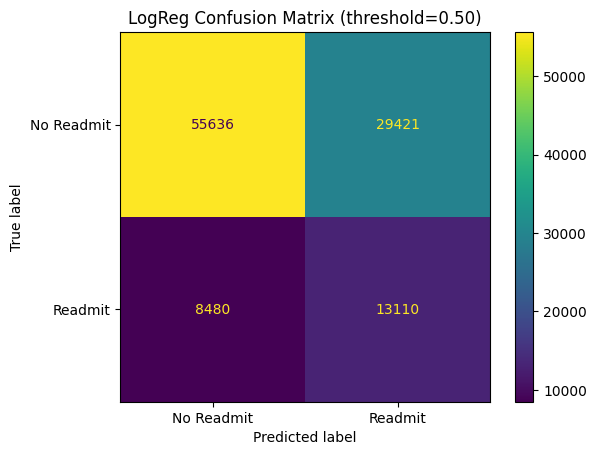

              precision    recall  f1-score   support

  No Readmit       0.87      0.65      0.75     85057
     Readmit       0.31      0.61      0.41     21590

    accuracy                           0.64    106647
   macro avg       0.59      0.63      0.58    106647
weighted avg       0.75      0.64      0.68    106647



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

best_t = 0.5  # simplify (matches your val result)

test_prob = clf_lr.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, test_prob)
pr_auc  = average_precision_score(y_test, test_prob)

print("LogReg Test ROC-AUC:", roc_auc)
print("LogReg Test PR-AUC :", pr_auc)

test_pred = (test_prob >= best_t).astype(int)

cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Readmit", "Readmit"])
disp.plot()
plt.title(f"LogReg Confusion Matrix (threshold={best_t:.2f})")
plt.show()

print(classification_report(y_test, test_pred, target_names=["No Readmit", "Readmit"]))

XGBoost Test ROC-AUC: 0.7148612395786379
XGBoost Test PR-AUC : 0.4123936309243754
Best threshold on val: 0.49999999999999994 Best val F1: 0.43995525011986575


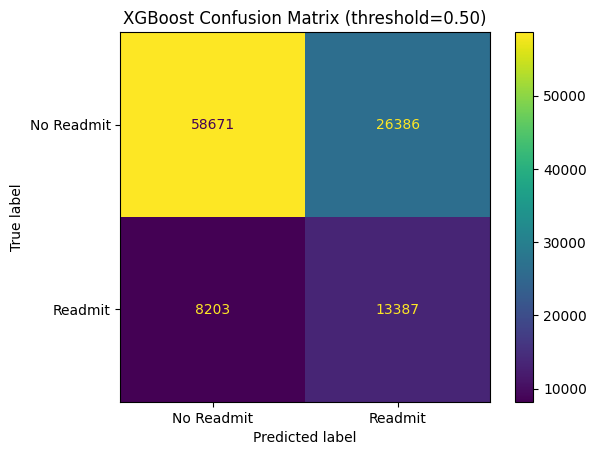

              precision    recall  f1-score   support

  No Readmit       0.88      0.69      0.77     85057
     Readmit       0.34      0.62      0.44     21590

    accuracy                           0.68    106647
   macro avg       0.61      0.65      0.60    106647
weighted avg       0.77      0.68      0.70    106647



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, f1_score
)

# Predict probabilities
test_prob = bst.predict(dtest, iteration_range=(0, bst.best_iteration + 1))

roc_auc = roc_auc_score(y_test_np, test_prob)
pr_auc  = average_precision_score(y_test_np, test_prob)

print("XGBoost Test ROC-AUC:", roc_auc)
print("XGBoost Test PR-AUC :", pr_auc)

# Pick threshold on VAL (maximize F1), then apply to TEST
val_prob = bst.predict(dval, iteration_range=(0, bst.best_iteration + 1))
thresholds = np.linspace(0.05, 0.95, 19)

best_t, best_f1 = None, -1
for t in thresholds:
    pred = (val_prob >= t).astype(int)
    f1 = f1_score(y_val_np, pred, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold on val:", best_t, "Best val F1:", best_f1)

test_pred = (test_prob >= best_t).astype(int)

cm = confusion_matrix(y_test_np, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Readmit", "Readmit"])
disp.plot()
plt.title(f"XGBoost Confusion Matrix (threshold={best_t:.2f})")
plt.show()

print(classification_report(y_test_np, test_pred, target_names=["No Readmit", "Readmit"]))

**Build lab features (v2)**


In [ ]:
FEATURES_V2_PATH = os.path.join(OUT_BASE, "features_v2_labs_full.csv")

if os.path.exists(FEATURES_V2_PATH):
    features_v2 = pd.read_csv(FEATURES_V2_PATH)
    print("Loaded cached features_v2_labs_full:", FEATURES_V2_PATH)
else:
    LAB_QUERIES = {
        "creatinine": ["creatinine"],
        "bun": ["bun", "urea nitrogen"],
        "sodium": ["sodium"],
        "potassium": ["potassium"],
        "chloride": ["chloride"],
        "bicarbonate": ["bicarbonate", "co2"],
        "glucose": ["glucose"],
        "hemoglobin": ["hemoglobin"],
        "wbc": ["white blood cell", "wbc"],
        "platelets": ["platelet"],
    }

    def find_itemids(dlabs, keywords):
        pat = "|".join([k.lower() for k in keywords])
        m = dlabs["label"].fillna("").str.lower().str.contains(pat, regex=True)
        return dlabs.loc[m, ["itemid","label"]].drop_duplicates()

    hadm_ids = set(model_df["hadm_id"].astype(int).unique())

    panel_map = {}
    for labname, keys in LAB_QUERIES.items():
        hits = find_itemids(d_labitems, keys)
        panel_map[labname] = hits["itemid"].astype(int).tolist()

    PANEL_ITEMIDS = sorted(set([iid for v in panel_map.values() for iid in v]))
    print("Total itemids in panel:", len(PANEL_ITEMIDS))

    last_time, last_val = {}, {}
    sum_val, cnt_val, min_val, max_val = {}, {}, {}, {}

    usecols = ["hadm_id", "itemid", "charttime", "valuenum"]
    chunksize = 1_000_000

    for i, chunk in enumerate(pd.read_csv(labs_path, compression="gzip", usecols=usecols, chunksize=chunksize), start=1):
        chunk = chunk[chunk["hadm_id"].isin(hadm_ids)]
        chunk = chunk[chunk["itemid"].isin(PANEL_ITEMIDS)]
        chunk = chunk.dropna(subset=["valuenum"])
        if chunk.empty:
            continue

        chunk["charttime"] = pd.to_datetime(chunk["charttime"], errors="coerce")
        chunk = chunk.dropna(subset=["charttime"])
        if chunk.empty:
            continue

        for (hid, iid), grp in chunk.groupby(["hadm_id","itemid"]):
            vals = grp["valuenum"].astype(float).values
            key = (int(hid), int(iid))

            sum_val[key] = sum_val.get(key, 0.0) + float(vals.sum())
            cnt_val[key] = cnt_val.get(key, 0) + int(len(vals))

            mn, mx = float(vals.min()), float(vals.max())
            min_val[key] = mn if key not in min_val else min(min_val[key], mn)
            max_val[key] = mx if key not in max_val else max(max_val[key], mx)

        idx = chunk.sort_values("charttime").groupby(["hadm_id","itemid"]).tail(1)
        for _, row in idx.iterrows():
            key = (int(row["hadm_id"]), int(row["itemid"]))
            t = row["charttime"]
            v = float(row["valuenum"])
            if (key not in last_time) or (t > last_time[key]):
                last_time[key] = t
                last_val[key]  = v

        if i % 25 == 0:
            print(f"Processed chunk {i} | keys: {len(cnt_val)}")

    rows = []
    for (hid, iid) in cnt_val.keys():
        rows.append({
            "hadm_id": hid,
            "itemid": iid,
            "lab_mean": sum_val[(hid,iid)] / cnt_val[(hid,iid)],
            "lab_min": min_val[(hid,iid)],
            "lab_max": max_val[(hid,iid)],
            "lab_last": last_val.get((hid,iid), np.nan),
        })
    labs_agg = pd.DataFrame(rows)

    itemid_to_lab = {}
    for labname, ids in panel_map.items():
        for iid in ids:
            itemid_to_lab.setdefault(int(iid), labname)

    labs_agg["lab"] = labs_agg["itemid"].map(itemid_to_lab)
    labs_agg = labs_agg.dropna(subset=["lab"]).copy()

    wide = labs_agg.pivot_table(
        index="hadm_id",
        columns="lab",
        values=["lab_last","lab_mean","lab_min","lab_max"],
        aggfunc="mean"
    )
    wide.columns = [f"{stat}_{lab}" for stat, lab in wide.columns]
    wide = wide.reset_index()

    features_v2 = model_df.merge(wide, on="hadm_id", how="left")

    for lab in LAB_QUERIES.keys():
        col = f"lab_last_{lab}"
        if col in features_v2.columns:
            features_v2[f"{lab}_missing"] = features_v2[col].isna().astype(int)

    features_v2.to_csv(FEATURES_V2_PATH, index=False)
    print("Saved features_v2_labs_full:", FEATURES_V2_PATH)

print("features_v2:", features_v2.shape)

Loaded cached features_v2_labs_full: /content/drive/MyDrive/mimic/features_v2_labs_full.csv
features_v2: (534000, 82)


**Prepare train/val/test from v2**

In [ ]:
train_df = subset_by_ids(features_v2, train_ids)
val_df   = subset_by_ids(features_v2, val_ids)
test_df  = subset_by_ids(features_v2, test_ids)

y_col = "readmit_30d"

base_features = [
    "anchor_age", "gender",
    "admission_type", "admission_location", "discharge_location",
    "insurance", "language", "marital_status", "race",
    "prior_admits_all", "days_since_last_discharge", "no_prior_admission",
    "is_snf_discharge",
    "los_days", "ed_los_hours", "ed_times_missing",
]

lab_features  = [c for c in features_v2.columns if c.startswith(("lab_last_", "lab_mean_", "lab_min_", "lab_max_"))]
missing_flags = [c for c in features_v2.columns if c.endswith("_missing")]

feature_cols = sorted(set([c for c in base_features if c in features_v2.columns] + lab_features + missing_flags))

X_train = train_df[feature_cols].copy()
y_train = train_df[y_col].astype(int).values

X_val   = val_df[feature_cols].copy()
y_val   = val_df[y_col].astype(int).values

X_test  = test_df[feature_cols].copy()
y_test  = test_df[y_col].astype(int).values

print("Features:", len(feature_cols))
print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)
print("Test positives:", int(y_test.sum()))

Features: 66
Train/Val/Test: (319833, 66) (107520, 66) (106647, 66)
Test positives: 21590


In [ ]:
def compute_metrics(y_true, prob, threshold=0.50):
    y_pred = (prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "ROC_AUC": roc_auc_score(y_true, prob),
        "PR_AUC": average_precision_score(y_true, prob),
        "Brier": brier_score_loss(y_true, prob),
        "Precision(Readmit)": tp / (tp + fp + 1e-12),
        "Recall(Readmit)": tp / (tp + fn + 1e-12),
        "F1(Readmit)": 2*tp / (2*tp + fp + fn + 1e-12),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "Threshold": threshold
    }

def plot_cm(y_true, prob, threshold=0.50, title="Confusion Matrix"):
    y_pred = (prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["No Readmit", "Readmit"]).plot()
    plt.title(f"{title} (t={threshold:.2f})")
    plt.show()
from sklearn.metrics import brier_score_loss

**Logistic Regression + labs**

LogReg+Labs metrics: {'ROC_AUC': np.float64(0.6868824547555807), 'PR_AUC': np.float64(0.36327494066623206), 'Brier': np.float64(0.22166149358665674), 'Precision(Readmit)': np.float64(0.3175623615525378), 'Recall(Readmit)': np.float64(0.6108846688281612), 'F1(Readmit)': np.float64(0.4178891670099173), 'TP': np.int64(13189), 'FP': np.int64(28343), 'FN': np.int64(8401), 'TN': np.int64(56714), 'Threshold': 0.5}


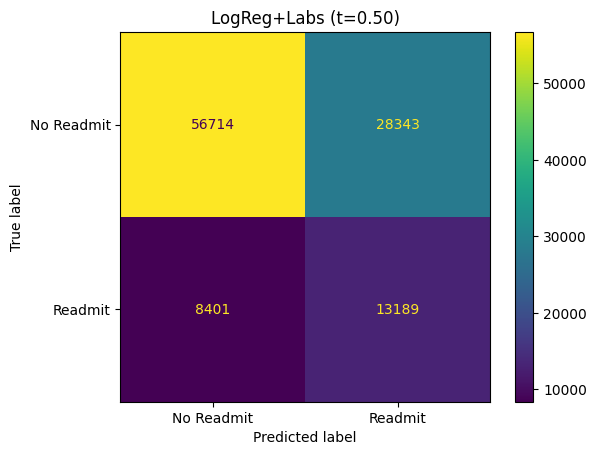

In [ ]:
from sklearn.linear_model import LogisticRegression

numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()

preprocess_lr = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), numeric_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore"))]), categorical_cols),
])

clf_lr_labs = Pipeline([
    ("preprocess", preprocess_lr),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

clf_lr_labs.fit(X_train, y_train)
prob_logreg = clf_lr_labs.predict_proba(X_test)[:, 1]

print("LogReg+Labs metrics:", compute_metrics(y_test, prob_logreg, 0.50))
plot_cm(y_test, prob_logreg, 0.50, "LogReg+Labs")

In [ ]:
# Save LogReg+Labs
joblib.dump(clf_lr_labs, os.path.join(MODELS_DIR, "logreg_v2_labs.joblib"))

with open(os.path.join(MODELS_DIR, "logreg_v2_labs_metrics.json"), "w") as f:
    json.dump({"model":"logreg_v2_labs", **compute_metrics(y_test, prob_logreg, 0.50)}, f, indent=2)

print("Saved LogReg+Labs model + metrics.")

**FCNN + labs**

In [ ]:
# Encoder for FCNN (dense output)
preprocess_nn = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), numeric_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=200))]), categorical_cols),
])

X_train_enc = preprocess_nn.fit_transform(X_train)
X_val_enc   = preprocess_nn.transform(X_val)
X_test_enc  = preprocess_nn.transform(X_test)

def to_dense(x):
    if sp.issparse(x):
        return x.toarray().astype(np.float32)
    return x.astype(np.float32)

X_train_d = to_dense(X_train_enc)
X_val_d   = to_dense(X_val_enc)
X_test_d  = to_dense(X_test_enc)

print("Encoded shapes:", X_train_d.shape, X_val_d.shape, X_test_d.shape)

Encoded shapes: (319833, 151) (107520, 151) (106647, 151)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {0: float(weights[0]), 1: float(weights[1])}
print("class_weight:", class_weight)

class_weight: {0: 0.6288374196339042, 1: 2.4404300451715297}


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(RANDOM_STATE)

input_dim = X_train_d.shape[1]

model_nn = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model_nn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.AUC(name="auc_roc"),
        keras.metrics.AUC(curve="PR", name="auc_pr")
    ]
)

ckpt_path = os.path.join(MODELS_DIR, "fcnn_v2_labs.keras")

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_auc_pr", mode="max", patience=5, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_auc_pr", mode="max", save_best_only=True),
]

history = model_nn.fit(
    X_train_d, y_train,
    validation_data=(X_val_d, y_val),
    epochs=50,
    batch_size=256,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

print("Saved best FCNN checkpoint:", ckpt_path)

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - auc_pr: 0.3739 - auc_roc: 0.6891 - loss: 0.6372 - val_auc_pr: 0.3966 - val_auc_roc: 0.7035 - val_loss: 0.6133
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - auc_pr: 0.3988 - auc_roc: 0.7064 - loss: 0.6253 - val_auc_pr: 0.4058 - val_auc_roc: 0.7079 - val_loss: 0.6100
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - auc_pr: 0.4078 - auc_roc: 0.7119 - loss: 0.6214 - val_auc_pr: 0.4098 - val_auc_roc: 0.7097 - val_loss: 0.6063
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - auc_pr: 0.4128 - auc_roc: 0.7154 - loss: 0.6187 - val_auc_pr: 0.4127 - val_auc_roc: 0.7110 - val_loss: 0.6089
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - auc_pr: 0.4181 - auc_roc: 0.7177 - loss: 0.6168 - val_auc_pr: 0.4173 - val_auc_roc: 0.7132 - val_loss: 0.6038
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - auc_pr: 0.4207 - auc_roc: 0.7196 - loss: 0.6155 - val_auc_pr: 0.4170 - val_auc_roc: 0.7128 - val_loss: 0.6026

105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
FCNN+Labs metrics: {'ROC_AUC': np.float64(0.7162044739058264), 'PR_AUC': np.float64(0.41786960171724824), 'Brier': np.float64(0.2049995475640242), 'Precision(Readmit)': np.float64(0.3397503648900297), 'Recall(Readmit)': np.float64(0.6253358036127837), 'F1(Readmit)': np.float64(0.44028828593790764), 'TP': np.int64(13501), 'FP': np.int64(26237), 'FN': np.int64(8089), 'TN': np.int64(58820), 'Threshold': 0.5}


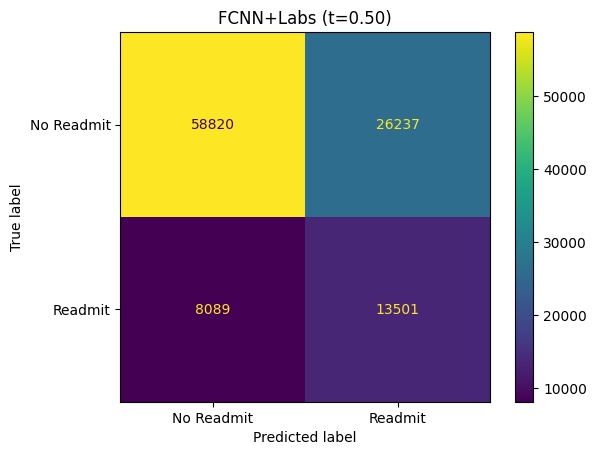

In [ ]:
prob_fcnn = model_nn.predict(X_test_d, batch_size=1024).ravel()

print("FCNN+Labs metrics:", compute_metrics(y_test, prob_fcnn, 0.50))
plot_cm(y_test, prob_fcnn, 0.50, "FCNN+Labs")

**XGBoost + Labs**

In [ ]:
!pip -q install xgboost==2.0.3 shap
import xgboost as xgb
import shap

print("XGBoost version:", xgb.__version__)
print("SHAP version   :", shap.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.1/297.1 MB 5.4 MB/s eta 0:00:00
XGBoost version: 2.0.3
SHAP version   : 0.51.0


In [ ]:
# Encoder for XGB: match your retrain pipeline
preprocess_xgb = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), numeric_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=200))]), categorical_cols),
])

X_train_enc_xgb = preprocess_xgb.fit_transform(X_train)
X_val_enc_xgb   = preprocess_xgb.transform(X_val)
X_test_enc_xgb  = preprocess_xgb.transform(X_test)

print("Encoded shapes:", X_train_enc_xgb.shape, X_val_enc_xgb.shape, X_test_enc_xgb.shape,
      "| sparse?", sp.issparse(X_train_enc_xgb))

dtrain = xgb.DMatrix(X_train_enc_xgb, label=y_train)
dval   = xgb.DMatrix(X_val_enc_xgb,   label=y_val)
dtest  = xgb.DMatrix(X_test_enc_xgb,  label=y_test)

pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

Encoded shapes: (319833, 151) (107520, 151) (106647, 151) | sparse? False
scale_pos_weight: 3.8808600903430595


[0]	train-logloss:0.68853	train-auc:0.66589	train-aucpr:0.36506	val-logloss:0.68867	val-auc:0.66161	val-aucpr:0.36313
[200]	train-logloss:0.60999	train-auc:0.72456	train-aucpr:0.43144	val-logloss:0.61569	val-auc:0.71512	val-aucpr:0.42016
[400]	train-logloss:0.60205	train-auc:0.73462	train-aucpr:0.44571	val-logloss:0.61019	val-auc:0.71988	val-aucpr:0.42630
[600]	train-logloss:0.59636	train-auc:0.74199	train-aucpr:0.45635	val-logloss:0.60709	val-auc:0.72183	val-aucpr:0.42920
[800]	train-logloss:0.59152	train-auc:0.74852	train-aucpr:0.46529	val-logloss:0.60490	val-auc:0.72271	val-aucpr:0.43074
[1000]	train-logloss:0.58719	train-auc:0.75428	train-aucpr:0.47349	val-logloss:0.60316	val-auc:0.72323	val-aucpr:0.43159
[1200]	train-logloss:0.58269	train-auc:0.75966	train-aucpr:0.48131	val-logloss:0.60122	val-auc:0.72349	val-aucpr:0.43243
[1388]	train-logloss:0.57907	train-auc:0.76441	train-aucpr:0.48848	val-logloss:0.60001	val-auc:0.72343	val-aucpr:0.43264
Trained XGB. Best iteration: 1338
XGB+L

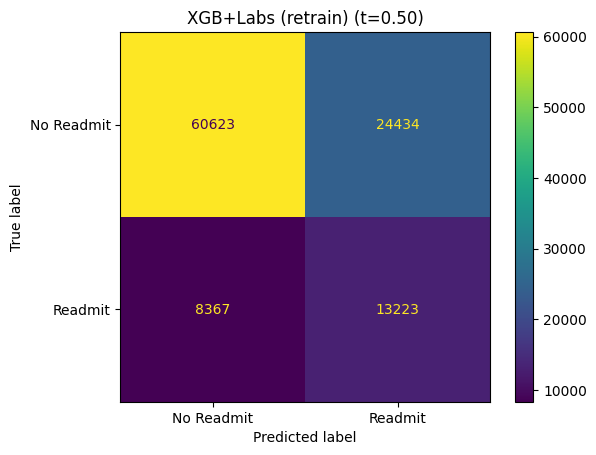

In [ ]:
params = {
    "objective": "binary:logistic",
    "eval_metric": ["logloss", "auc", "aucpr"],
    "learning_rate": 0.05,
    "max_depth": 4,
    "min_child_weight": 1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "lambda": 1.0,
    "scale_pos_weight": scale_pos_weight,
    "seed": RANDOM_STATE,
    "tree_method": "hist",
}

bst_re = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=4000,
    evals=[(dtrain,"train"), (dval,"val")],
    early_stopping_rounds=50,
    verbose_eval=200
)

best_iter = int(bst_re.best_iteration)
print("Trained XGB. Best iteration:", best_iter)

prob_xgb_val  = bst_re.predict(dval,  iteration_range=(0, best_iter+1))
prob_xgb_test = bst_re.predict(dtest, iteration_range=(0, best_iter+1))

print("XGB+Labs metrics:", compute_metrics(y_test, prob_xgb_test, 0.50))
plot_cm(y_test, prob_xgb_test, 0.50, "XGB+Labs (retrain)")

**Final Results Table**

In [ ]:
t = 0.50

rows = []
rows.append({"Model": "LogReg+Labs", **compute_metrics(y_test, prob_logreg, threshold=t)})
rows.append({"Model": "FCNN+Labs",   **compute_metrics(y_test, prob_fcnn,  threshold=t)})
rows.append({"Model": "XGB+Labs (retrain)", **compute_metrics(y_test, prob_xgb_test, threshold=t)})

results = pd.DataFrame(rows)

col_order = [
    "Model", "ROC_AUC", "PR_AUC", "Brier",
    "Precision(Readmit)", "Recall(Readmit)", "F1(Readmit)",
    "TP", "FP", "FN", "TN", "Threshold"
]
results = results[col_order].sort_values("PR_AUC", ascending=False)

display(results)

print("\nWinner by PR-AUC:", results.iloc[0]["Model"])
print("Winner by Brier (lowest):", results.sort_values("Brier").iloc[0]["Model"])

,Model,ROC_AUC,PR_AUC,Brier,Precision(Readmit),Recall(Readmit),F1(Readmit),TP,FP,FN,TN,Threshold
2,XGB+Labs (retrain),0.724144,0.429847,0.204915,0.351143,0.612459,0.446369,13223,24434,8367,60623,0.5
1,FCNN+Labs,0.716204,0.417870,0.205000,0.339750,0.625336,0.440288,13501,26237,8089,58820,0.5
0,LogReg+Labs,0.686882,0.363275,0.221661,0.317562,0.610885,0.417889,13189,28343,8401,56714,0.5



Winner by PR-AUC: XGB+Labs (retrain)
Winner by Brier (lowest): XGB+Labs (retrain)


**Calibration**

In [ ]:
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression as LR

#  Platt scaling (logistic regression on validation probs)
platt = LR(solver="lbfgs")
platt.fit(prob_xgb_val.reshape(-1,1), y_val)

prob_xgb_val_platt  = platt.predict_proba(prob_xgb_val.reshape(-1,1))[:,1]
prob_xgb_test_platt = platt.predict_proba(prob_xgb_test.reshape(-1,1))[:,1]

# Isotonic scaling
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(prob_xgb_val, y_val)

prob_xgb_val_iso  = iso.transform(prob_xgb_val)
prob_xgb_test_iso = iso.transform(prob_xgb_test)

def calib_report(name, prob):
    return {
        "name": name,
        "PR_AUC": average_precision_score(y_test, prob),
        "ROC_AUC": roc_auc_score(y_test, prob),
        "Brier": brier_score_loss(y_test, prob)
    }

raw_r   = calib_report("RAW", prob_xgb_test)
platt_r = calib_report("Platt", prob_xgb_test_platt)
iso_r   = calib_report("Iso", prob_xgb_test_iso)

print("=== XGB+Labs (retrain) calibration comparison on TEST ===")
for r in [raw_r, platt_r, iso_r]:
    print(f"{r['name']:5s} | PR-AUC: {r['PR_AUC']:.6f} | ROC-AUC: {r['ROC_AUC']:.6f} | Brier: {r['Brier']:.6f}")

=== XGB+Labs (retrain) calibration comparison on TEST ===
RAW   | PR-AUC: 0.429847 | ROC-AUC: 0.724144 | Brier: 0.204915
Platt | PR-AUC: 0.429847 | ROC-AUC: 0.724144 | Brier: 0.142132
Iso   | PR-AUC: 0.423239 | ROC-AUC: 0.723916 | Brier: 0.141900


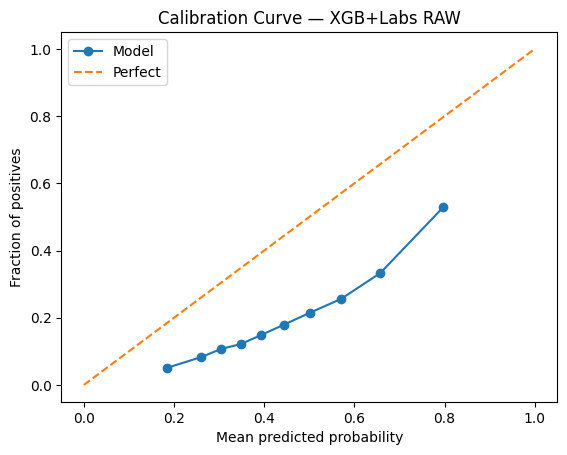

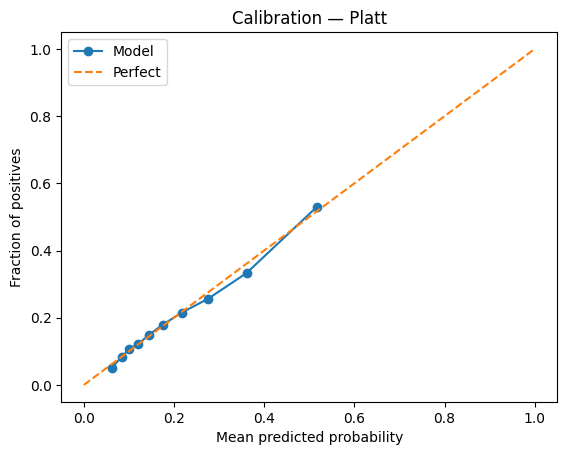

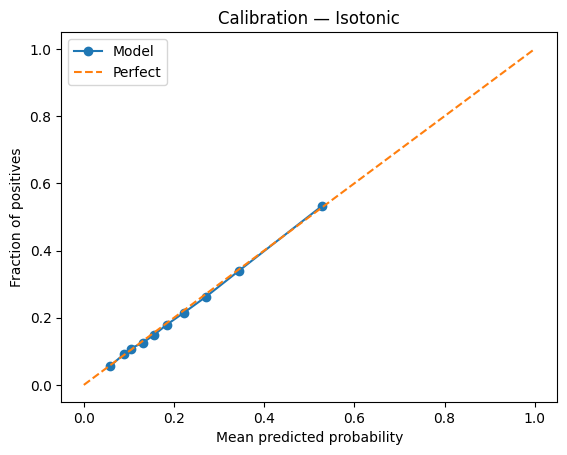

In [ ]:
from sklearn.calibration import calibration_curve

def plot_calib(prob, title):
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10, strategy="quantile")
    plt.figure()
    plt.plot(mean_pred, frac_pos, marker="o", label="Model")
    plt.plot([0,1],[0,1],"--", label="Perfect")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title(title)
    plt.legend()
    plt.show()

plot_calib(prob_xgb_test,       "Calibration Curve — XGB+Labs RAW")
plot_calib(prob_xgb_test_platt, "Calibration — Platt")
plot_calib(prob_xgb_test_iso,   "Calibration — Isotonic")

**Risk Tiers**

In [ ]:
# Use calibrated probabilities consistently for tiers
prob_final_val  = prob_xgb_val_platt
prob_final_test = prob_xgb_test_platt

low_cut  = np.quantile(prob_final_val, 0.70)
high_cut = np.quantile(prob_final_val, 0.90)

def tier(p):
    if p >= high_cut: return "HIGH"
    if p >= low_cut:  return "MED"
    return "LOW"

print("Tier cutoffs from VAL:")
print(" low_cut =", low_cut)
print(" high_cut=", high_cut)

tiers_test = pd.Series([tier(p) for p in prob_final_test]).value_counts()
print("\nTier counts on TEST:")
print(tiers_test)

Tier cutoffs from VAL:
 low_cut = 0.2440573660128243
 high_cut= 0.42192877466842615

Tier counts on TEST:
LOW     74938
MED     21273
HIGH    10436
Name: count, dtype: int64


**Demo Table**

In [ ]:
demo = test_df[["subject_id","hadm_id","discharge_location","los_days","prior_admits_all"]].copy()
demo["risk_prob"] = prob_final_test
demo["tier"] = [tier(p) for p in demo["risk_prob"]]

def suggested_action(t):
    if t == "HIGH":
        return "High risk → follow-up within 7 days; medication + care coordination review"
    if t == "MED":
        return "Medium risk → post-discharge call within 48–72h; reinforce discharge plan"
    return "Low risk → standard discharge; routine follow-up"

demo["suggested_action"] = demo["tier"].apply(suggested_action)

# Balanced sample for presentation
high = demo[demo["tier"]=="HIGH"].sort_values("risk_prob", ascending=False).head(8)
med  = demo[demo["tier"]=="MED"].sort_values("risk_prob", ascending=False).head(6)
low  = demo[demo["tier"]=="LOW"].sort_values("risk_prob", ascending=False).head(6)

demo_shap = pd.concat([high, med, low], axis=0).reset_index(drop=True)
print("demo_shap size:", demo_shap.shape)
display(demo_shap)

demo_shap size: (20, 8)


,subject_id,hadm_id,discharge_location,los_days,prior_admits_all,risk_prob,tier,suggested_action
0,14873634,28203922,ACUTE HOSPITAL,0.057639,18,0.720053,HIGH,High risk → follow-up within 7 days; medication + care coordination review
1,15421879,24801671,ACUTE HOSPITAL,1.340278,35,0.717454,HIGH,High risk → follow-up within 7 days; medication + care coordination review
2,14873634,26795218,ACUTE HOSPITAL,0.034028,19,0.715939,HIGH,High risk → follow-up within 7 days; medication + care coordination review
3,15208175,22390794,ACUTE HOSPITAL,0.288889,1,0.707614,HIGH,High risk → follow-up within 7 days; medication + care coordination review
4,14873634,22627318,ACUTE HOSPITAL,4.790278,26,0.707391,HIGH,High risk → follow-up within 7 days; medication + care coordination review
5,10714009,22160172,NaN,0.074306,160,0.707083,HIGH,High risk → follow-up within 7 days; medication + care coordination review
6,14873634,26572450,ACUTE HOSPITAL,29.443750,24,0.705656,HIGH,High risk → follow-up within 7 days; medication + care coordination review
7,14873634,20466602,PSYCH FACILITY,0.300694,15,0.705502,HIGH,High risk → follow-up within 7 days; medication + care coordination review
8,12070236,20175914,NaN,0.093056,2,0.421907,MED,Medium risk → post-discharge call within 48–72h; reinforce discharge plan
9,18036964,27461189,SKILLED NURSING FACILITY,4.688194,20,0.421907,MED,Medium risk → post-discharge call within 48–72h; reinforce discharge plan


**SHAP Top Reasons**

In [ ]:
# Feature names from ColumnTransformer (aligned with X_train_enc_xgb)
feature_names = preprocess_xgb.get_feature_names_out()
feature_names = [str(f) for f in feature_names]

def prettify_feature(name: str) -> str:
    name = name.replace("num__", "").replace("cat__", "")
    if "_" in name:
        col, rest = name.split("_", 1)
        if col in {"gender","admission_type","admission_location","discharge_location",
                   "insurance","language","marital_status","race"}:
            return f"{col} = {rest}"
    return name

pretty_names = [prettify_feature(n) for n in feature_names]
print("Feature names:", len(pretty_names))
print("Example:", pretty_names[:10])

Feature names: 151
Example: ['anchor_age', 'bicarbonate_missing', 'bun_missing', 'chloride_missing', 'creatinine_missing', 'days_since_last_discharge', 'ed_los_hours', 'ed_times_missing', 'glucose_missing', 'hemoglobin_missing']


In [ ]:
# Build matrix for demo_shap rows in the same encoding space
X_demo = demo_shap.merge(test_df[["hadm_id"]], on="hadm_id", how="left")  # safe merge (no-op)
X_demo_raw = test_df.set_index("hadm_id").loc[demo_shap["hadm_id"], feature_cols].reset_index(drop=True)

X_demo_enc = preprocess_xgb.transform(X_demo_raw)

explainer = shap.TreeExplainer(bst_re)
shap_vals = explainer.shap_values(X_demo_enc)

# shap_vals: (n_rows, n_features)
print("SHAP shape:", np.array(shap_vals).shape)

SHAP shape: (20, 151)


In [ ]:
def top_reasons_from_shap(shap_row, k=3):
    shap_row = np.asarray(shap_row, dtype=float)
    pos_idx = np.where(shap_row > 0)[0]
    if len(pos_idx) == 0:
        return ["No strong positive drivers"]
    top_idx = pos_idx[np.argsort(shap_row[pos_idx])[::-1][:k]]
    return [pretty_names[i] for i in top_idx]

demo_shap = demo_shap.copy()
demo_shap["top_reasons"] = [
    "; ".join(top_reasons_from_shap(shap_vals[i], k=3))
    for i in range(len(demo_shap))
]

# Show a clean, readable table (balanced tiers)
cols_to_show = ["subject_id","hadm_id","risk_prob","tier","top_reasons","suggested_action"]
display(demo_shap[cols_to_show])

,subject_id,hadm_id,risk_prob,tier,top_reasons,suggested_action
0,14873634,28203922,0.720053,HIGH,discharge_location_ACUTE HOSPITAL; days_since_last_discharge; los_days,High risk → follow-up within 7 days; medication + care coordination review
1,15421879,24801671,0.717454,HIGH,discharge_location_ACUTE HOSPITAL; days_since_last_discharge; prior_admits_all,High risk → follow-up within 7 days; medication + care coordination review
2,14873634,26795218,0.715939,HIGH,discharge_location_ACUTE HOSPITAL; days_since_last_discharge; los_days,High risk → follow-up within 7 days; medication + care coordination review
3,15208175,22390794,0.707614,HIGH,discharge_location_ACUTE HOSPITAL; days_since_last_discharge; los_days,High risk → follow-up within 7 days; medication + care coordination review
4,14873634,22627318,0.707391,HIGH,discharge_location_ACUTE HOSPITAL; days_since_last_discharge; prior_admits_all,High risk → follow-up within 7 days; medication + care coordination review
5,10714009,22160172,0.707083,HIGH,prior_admits_all; days_since_last_discharge; los_days,High risk → follow-up within 7 days; medication + care coordination review
6,14873634,26572450,0.705656,HIGH,discharge_location_ACUTE HOSPITAL; days_since_last_discharge; prior_admits_all,High risk → follow-up within 7 days; medication + care coordination review
7,14873634,20466602,0.705502,HIGH,discharge_location_PSYCH FACILITY; los_days; prior_admits_all,High risk → follow-up within 7 days; medication + care coordination review
8,12070236,20175914,0.421907,MED,los_days; admission_location_EMERGENCY ROOM; ed_los_hours,Medium risk → post-discharge call within 48–72h; reinforce discharge plan
9,18036964,27461189,0.421907,MED,prior_admits_all; days_since_last_discharge; lab_last_bicarbonate,Medium risk → post-discharge call within 48–72h; reinforce discharge plan


**Fairness/subgroup checks**

In [ ]:
# Threshold used for subgroup recall
t = 0.50
y_pred = (prob_final_test >= t).astype(int)

# Merge needed columns for subgroup slicing
fair_df = test_df[["subject_id","hadm_id","gender","anchor_age"]].copy()
fair_df["y_true"] = y_test
fair_df["prob"] = prob_final_test
fair_df["y_pred"] = y_pred

def subgroup_table(mask, label):
    sub = fair_df[mask]
    return {
        "group": label,
        "n": len(sub),
        "positives": int(sub["y_true"].sum()),
        "PR_AUC": average_precision_score(sub["y_true"], sub["prob"]) if sub["y_true"].nunique() > 1 else np.nan,
        "Recall@t": ( ((sub["y_true"]==1) & (sub["y_pred"]==1)).sum() / (sub["y_true"]==1).sum() ) if (sub["y_true"]==1).sum() > 0 else np.nan
    }

rows = []
rows.append(subgroup_table(fair_df["gender"]=="F", "gender=F"))
rows.append(subgroup_table(fair_df["gender"]=="M", "gender=M"))

sex_table = pd.DataFrame(rows)
display(sex_table)

,group,n,positives,PR_AUC,Recall@t
0,gender=F,55794,10520,0.412089,0.135456
1,gender=M,50853,11070,0.446102,0.174255


In [ ]:
def age_group(age):
    if age < 40: return "<40"
    if age < 65: return "40–65"
    return "65+"

fair_df["age_group"] = fair_df["anchor_age"].apply(age_group)

rows = []
for g in ["<40", "40–65", "65+"]:
    rows.append(subgroup_table(fair_df["age_group"]==g, f"age={g}"))

age_table = pd.DataFrame(rows)
display(age_table)

,group,n,positives,PR_AUC,Recall@t
0,age=<40,23106,4288,0.450876,0.186101
1,age=40–65,43938,9603,0.463886,0.205040
2,age=65+,39603,7699,0.369031,0.076244
